# TUBERCULOSIS DETECTION

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import albumentations as A


/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.3 (you have 1.4.15). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
# Paths
root_path = "/kaggle/input/xraydataset/Dataset"
image_path = os.path.join(root_path, "Chest-X-Ray", "image")
mask_path = os.path.join(root_path, "Chest-X-Ray", "mask")
metadata_path = os.path.join(root_path, "MetaData.csv")


In [3]:
# Load metadata
metadata = pd.read_csv(metadata_path)

# Match images and masks
image_ids = metadata['id'].astype(str)
image_files = [os.path.join(image_path, f"{img_id}.png") for img_id in image_ids]
mask_files = [os.path.join(mask_path, f"{img_id}.png") for img_id in image_ids]

# Add file paths to metadata
metadata['image_path'] = image_files
metadata['mask_path'] = mask_files

# Load images and masks
def load_and_preprocess_images(files, size=(512, 512)):
    images = []
    for file in files:
        img = cv2.imread(file, cv2.IMREAD_GRAYSCALE)
        img_resized = cv2.resize(img, size)
        images.append(img_resized)
    return np.array(images)

images = load_and_preprocess_images(metadata['image_path'].tolist())
masks = load_and_preprocess_images(metadata['mask_path'].tolist())

# Normalize images and masks
images = images / 255.0  # Scale to [0, 1]
masks = masks / 255.0  # Scale to [0, 1]
labels = metadata['ptb'].values  # Extract labels


In [4]:
# Augmentation pipeline
augmentor = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.ElasticTransform(p=0.2),
])

def augment_images_and_masks(images, masks):
    augmented_images, augmented_masks = [], []
    for img, mask in zip(images, masks):
        augmented = augmentor(image=img, mask=mask)
        augmented_images.append(augmented['image'])
        augmented_masks.append(augmented['mask'])
    return np.array(augmented_images), np.array(augmented_masks)


In [5]:
# Split data
train_imgs, test_imgs, train_masks, test_masks, train_labels, test_labels = train_test_split(
    images, masks, labels, test_size=0.2, stratify=labels, random_state=42
)

train_imgs, val_imgs, train_masks, val_masks, train_labels, val_labels = train_test_split(
    train_imgs, train_masks, train_labels, test_size=0.1, stratify=train_labels, random_state=42
)

# Augment training data
train_imgs_aug, train_masks_aug = augment_images_and_masks(train_imgs, train_masks)


In [6]:
def transformer_encoder(inputs, num_heads, mlp_dim, dropout_rate):
    x = layers.LayerNormalization()(inputs)
    x = layers.MultiHeadAttention(num_heads=num_heads, key_dim=inputs.shape[-1])(x, x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Add()([x, inputs])

    y = layers.LayerNormalization()(x)
    y = layers.Dense(mlp_dim, activation='relu')(y)
    y = layers.Dropout(dropout_rate)(y)
    y = layers.Dense(inputs.shape[-1])(y)
    y = layers.Dropout(dropout_rate)(y)
    return layers.Add()([x, y])

def unet_decoder(encoder_outputs, num_filters):
    x = encoder_outputs
    for filters in num_filters:
        x = layers.Conv2DTranspose(filters, (3, 3), strides=(2, 2), padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
    return x

def hybrid_transformer_unet(input_shape=(512, 512, 1), num_heads=8, mlp_dim=128, dropout_rate=0.1):
    inputs = layers.Input(shape=input_shape)
    patches = layers.Conv2D(64, (16, 16), strides=(16, 16), padding="same")(inputs)
    patches_flat = layers.Reshape((-1, patches.shape[-1]))(patches)

    encoded = patches_flat
    for _ in range(6):
        encoded = transformer_encoder(encoded, num_heads, mlp_dim, dropout_rate)

    encoder_output = layers.Reshape((patches.shape[1], patches.shape[2], patches.shape[-1]))(encoded)
    decoded = unet_decoder(encoder_output, [256, 128, 64, 32])

    segmentation_output = layers.Conv2D(1, (1, 1), activation="sigmoid", name="segmentation")(decoded)

    x = layers.GlobalAveragePooling2D()(encoder_output)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    classification_output = layers.Dense(1, activation="sigmoid", name="classification")(x)

    return Model(inputs, [segmentation_output, classification_output])


In [7]:
model = hybrid_transformer_unet()

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss={"segmentation": "binary_crossentropy", "classification": "binary_crossentropy"},
    metrics={"segmentation": ["accuracy"], "classification": ["accuracy", "AUC"]}
)

# Learning rate scheduler
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1, min_lr=1e-6)

# Train
history = model.fit(
    x=train_imgs_aug,
    y={"segmentation": train_masks_aug, "classification": train_labels},
    validation_data=(val_imgs, {"segmentation": val_masks, "classification": val_labels}),
    batch_size=16,
    epochs=100,
    callbacks=[lr_scheduler]
)


Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - classification_AUC: 0.4912 - classification_accuracy: 0.5124 - loss: 1.5354 - segmentation_accuracy: 0.5174 - val_classification_AUC: 0.5351 - val_classification_accuracy: 0.5088 - val_loss: 1.4159 - val_segmentation_accuracy: 0.2619 - learning_rate: 1.0000e-04
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 412ms/step - classification_AUC: 0.4252 - classification_accuracy: 0.4517 - loss: 1.3381 - segmentation_accuracy: 0.7150 - val_classification_AUC: 0.3812 - val_classification_accuracy: 0.4912 - val_loss: 1.4278 - val_segmentation_accuracy: 0.2635 - learning_rate: 1.0000e-04
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 410ms/step - classification_AUC: 0.4727 - classification_accuracy: 0.4793 - loss: 1.2297 - segmentation_accuracy: 0.8058 - val_classification_AUC: 0.6564 - val_classification_accuracy: 0.5439 - val_loss: 1.3561 - val_segmentation_accuracy: 0.6683 - learning_rate: 1.0000e-04
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 409ms

In [8]:
# Save the trained model
model.save("tb_detection_model.h5")


In [ ]:
from tensorflow.keras.models import load_model

# Load the saved model
model = load_model("tb_detection_model.h5", custom_objects={"accuracy": "accuracy", "AUC": "AUC"})


In [9]:
def preprocess_image(image_path, target_size=(512, 512)):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img_resized = cv2.resize(img, target_size)
    img_normalized = img_resized / 255.0
    img_processed = np.expand_dims(img_normalized, axis=(0, -1))
    return img_processed

def predict_tb(image_path):
    processed_image = preprocess_image(image_path)
    predicted_mask, tb_probability = model.predict(processed_image)
    tb_detected = "Tuberculosis Positive" if tb_probability[0][0] > 0.5 else "Tuberculosis Negative"
    predicted_mask = (predicted_mask[0] > 0.5).astype(np.uint8)
    return tb_detected, tb_probability[0][0], predicted_mask


In [10]:
def visualize_results(image_path, tb_detected, tb_probability, predicted_mask):
    # Load the original image
    original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Ensure predicted_mask is 2D
    predicted_mask = np.squeeze(predicted_mask)

    # Resize the predicted mask to match the original image dimensions
    predicted_mask_resized = cv2.resize(predicted_mask, (original_image.shape[1], original_image.shape[0]))
    predicted_mask_resized = (predicted_mask_resized > 0.5).astype(np.uint8)  # Binarize mask

    # Overlay the mask
    overlay = original_image.copy()
    overlay[predicted_mask_resized == 1] = 255  # Highlight TB areas in white

    # Display the results
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title(f"Original Image - {tb_detected} ({tb_probability:.2f})")
    plt.imshow(original_image, cmap="gray")
    plt.subplot(1, 2, 2)
    plt.title("Predicted TB Segmentation Mask")
    plt.imshow(overlay, cmap="gray")
    plt.show()


In [ ]:
# Evaluate
results = model.evaluate(
    x=test_imgs,
    y={"segmentation": test_masks, "classification": test_labels}
)
print("Final Test Results:", results)

# Visualize results
def overlay_mask(image, mask):
    mask = np.squeeze(mask)  # Remove the last dimension if present
    overlay = image.copy()
    overlay[mask > 0.5] = 255  # Overlay in white
    return overlay

predicted_masks, _ = model.predict(test_imgs)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(test_imgs[0], cmap="gray")
plt.subplot(1, 2, 2)
plt.title("Overlayed Mask")
plt.imshow(overlay_mask(test_imgs[0], predicted_masks[0]))
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


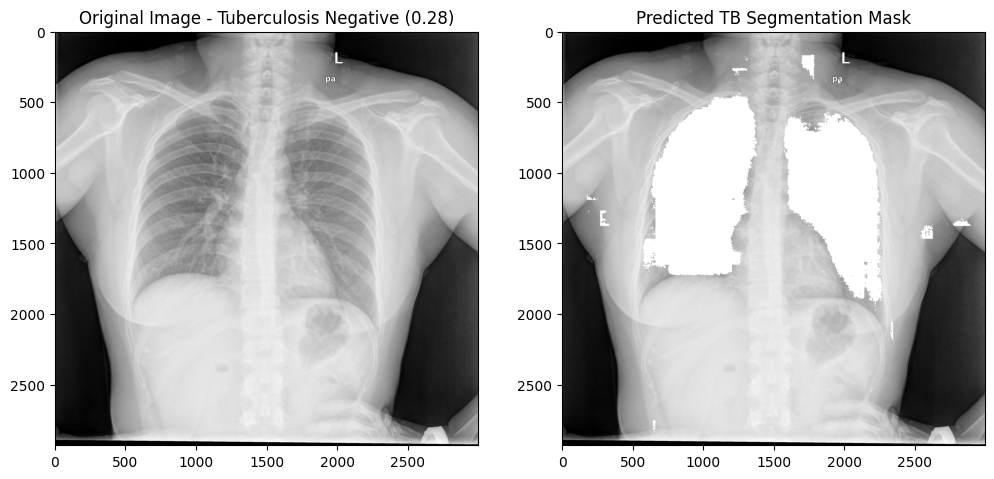

In [11]:
image_path = "/kaggle/input/xraydataset/Dataset/Chest-X-Ray/image/1144.png"
image_path = image_path
tb_detected, tb_probability, predicted_mask = predict_tb(image_path)
visualize_results(image_path, tb_detected, tb_probability, predicted_mask)


In [12]:
# Evaluate on test set
results = model.evaluate(
    x=test_imgs,
    y={"segmentation": test_masks, "classification": test_labels}
)

# Display results
print(f"Final Test Results:")
print(f"Segmentation Accuracy: {results[3]:.2f}")
print(f"Classification Accuracy: {results[2]:.2f}")
print(f"Classification AUC: {results[1]:.2f}")
print(f"Total Loss: {results[0]:.2f}")


5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - classification_AUC: 0.7692 - classification_accuracy: 0.6862 - loss: 0.7141 - segmentation_accuracy: 0.9520 
Final Test Results:
Segmentation Accuracy: 0.95
Classification Accuracy: 0.67
Classification AUC: 0.75
Total Loss: 0.75


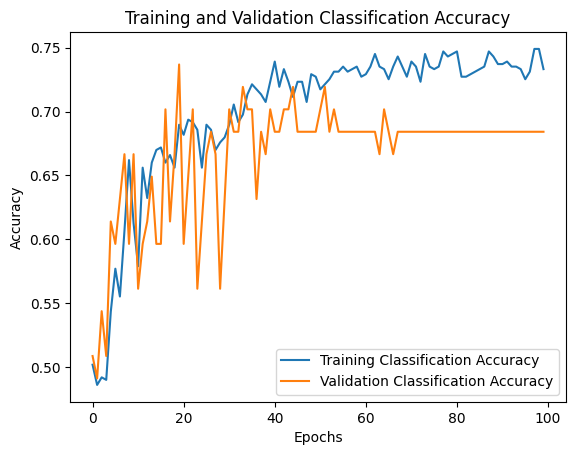

In [13]:
# Plot classification accuracy
plt.figure()
plt.plot(history.history['classification_accuracy'], label='Training Classification Accuracy')
plt.plot(history.history['val_classification_accuracy'], label='Validation Classification Accuracy')
plt.title('Training and Validation Classification Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


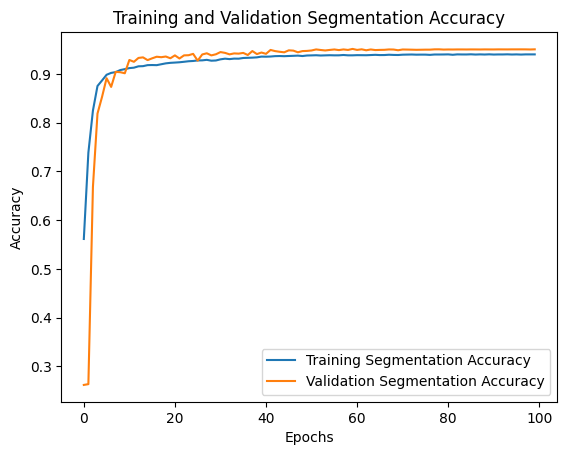

In [14]:
# Plot segmentation accuracy
plt.figure()
plt.plot(history.history['segmentation_accuracy'], label='Training Segmentation Accuracy')
plt.plot(history.history['val_segmentation_accuracy'], label='Validation Segmentation Accuracy')
plt.title('Training and Validation Segmentation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


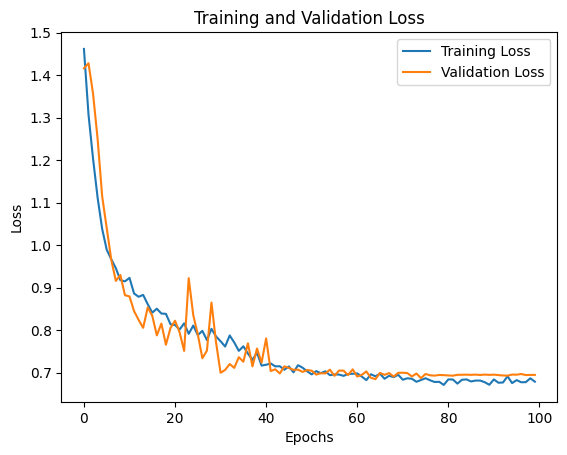

In [15]:
# Plot training and validation loss
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import roc_curve, auc

# Predict outputs for the test set
predictions = model.predict(test_imgs)
segmentation_output, classification_probs = predictions  # Unpack the outputs

# Flatten test labels if necessary
if len(test_labels.shape) > 1:
    test_labels = test_labels.flatten()

# Compute ROC curve and AUC for the classification task
fpr, tpr, thresholds = roc_curve(test_labels, classification_probs)
roc_auc = auc(fpr, tpr)

# Plot the ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for TB Classification')
plt.legend(loc="lower right")
plt.show()


In [26]:
# Print the model summary
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 512, 512, 1)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 32, 32, 64)     │         16,448 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape (Reshape)         │ (None, 1024, 64)       │              0 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization       │ (None, 1024, 64)       │            128 │ reshape[0][0]          │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention      │ (None, 1024, 64)       │        132,672 │ layer_normalization[0… │
│ (MultiHeadAttention)      │                        │                │ layer_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 1024, 64)       │              0 │ multi_head_attention[… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 1024, 64)       │              0 │ dropout_1[0][0],       │
│                           │                        │                │ reshape[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_1     │ (None, 1024, 64)       │            128 │ add[0][0]              │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 1024, 128)      │          8,320 │ layer_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, 1024, 128)      │              0 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 1024, 64)       │          8,256 │ dropout_2[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_3 (Dropout)       │ (None, 1024, 64)       │              0 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_1 (Add)               │ (None, 1024, 64)       │              0 │ add[0][0],             │
│                           │                        │                │ dropout_3[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_2     │ (None, 1024, 64)       │            128 │ add_1[0][0]            │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention_1    │ (None, 1024, 64)       │        132,672 │ layer_normalization_2… │
│ (MultiHeadAttention)      │                        │                │ layer_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_5 (Dropout)       │ (None, 1024, 64)       │              0 │ multi_head_attention_… │
├──────────────────────

 Total params: 6,853,736 (26.14 MB)

 Trainable params: 2,283,938 (8.71 MB)

 Non-trainable params: 1,920 (7.50 KB)

 Optimizer params: 4,567,878 (17.43 MB)

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load metadata CSV
metadata_path = "/kaggle/input/xraydataset/Dataset/MetaData.csv"
metadata = pd.read_csv(metadata_path)

# Display the first few rows
print(metadata.head())

# Columns in metadata
print("Columns in metadata:", metadata.columns)


     id gender age    county  ptb                                      remarks
0  1000   male  31  Shenxhen    0                                       normal
1  1001   male  64  Shenxhen    0                                       normal
2  1002   male  35  Shenxhen    0                                       normal
3  1003   male  32  Shenxhen    1               STB,ATB,tuberculosis pleuritis
4  1004   male   2  Shenxhen    1  secondary PTB  in the bilateral upper field
Columns in metadata: Index(['id', 'gender', 'age', 'county', 'ptb', 'remarks'], dtype='object')


Class Distribution:
ptb
0    359
1    345
Name: count, dtype: int64


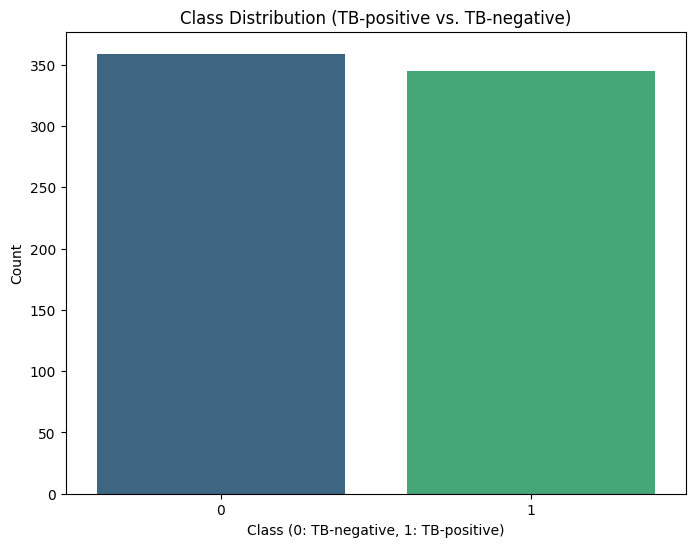

In [20]:
# Count TB-positive and TB-negative cases
class_counts = metadata['ptb'].value_counts()
print("Class Distribution:")
print(class_counts)

# Plot class distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Class Distribution (TB-positive vs. TB-negative)")
plt.xlabel("Class (0: TB-negative, 1: TB-positive)")
plt.ylabel("Count")
plt.show()


In [21]:
print(metadata.dtypes)
# Example: Check unique values in the 'age' column
print(metadata['age'].unique())


id          int64
gender     object
age        object
county     object
ptb         int64
remarks    object
dtype: object
['31' '64' '35' '32' '2' '17' '25' '30' '27' '37' '26' '46' '57' '23' '33'
 '45' '74' '48' '20' '56' '39' '43' '38' '65' '28' '47' '60' '29' '34' '5'
 '22' '24' '68' '42' '18' '1' '78' '53' '21' '59' '8' '63' '75' '19' '36'
 '51' '40' '69' '61' '41' '15' '49' '52' '62' '85' '50' '44' '71' '10'
 '58' '55' '1yr' '6' '76' '7' '54' '39yr' '16month' '3' '67' '81' 'male35'
 '70' 'female24' '14' '82' '89' '035' '032' '061' '046' '077' '049' '053'
 '043' '039' '030' '024' '037' '028' '009' '011' '063' '031' '067' '021'
 '052' '038' '044' '054' '088' '014' '047' '042' '020' '008' '033' '034'
 '051' '005' '015' '025' '016' '045' '048' '069' '065' '036' '050' '056'
 '089' '017' '041' '027' '023' '026' '029' '070' '018' '040' '010' '019'
 '004' '084' '085' '068' '059' '073']


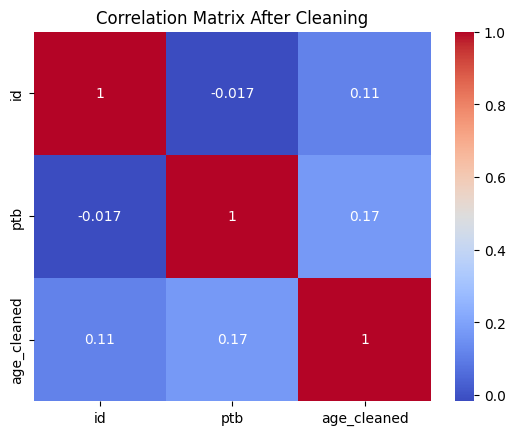

In [22]:
# Step 1: Extract numeric values from `age` column
metadata['age_cleaned'] = metadata['age'].str.extract('(\d+)')[0].astype(float)

# Step 2: Handle specific cases like "1yr" and "16month"
metadata.loc[metadata['age'] == '1yr', 'age_cleaned'] = 1.0
metadata.loc[metadata['age'] == '16month', 'age_cleaned'] = 1.33

# Step 3: Handle embedded gender information
metadata.loc[metadata['age'].str.contains('male', na=False), 'gender'] = 1  # Male: 1
metadata.loc[metadata['age'].str.contains('female', na=False), 'gender'] = 0  # Female: 0

# Step 4: Ensure `age_cleaned` is float type for further processing
metadata['age_cleaned'] = metadata['age_cleaned'].astype(float)

# Step 5: Fill remaining NaN values with the median age
metadata['age_cleaned'].fillna(metadata['age_cleaned'].median(), inplace=True)


# Select only numeric columns for correlation
numeric_metadata = metadata.select_dtypes(include=[np.number])

# Compute correlation matrix
correlation_matrix = numeric_metadata.corr()

# Visualize the correlation matrix
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix After Cleaning")
plt.show()
